# 🏎️ Notebook 3: Entrenamiento y Evaluación Comparativa de Modelos

## TFM: Predicción de Estrategias de Carrera en Fórmula 1 mediante ML

**Autor:** Francisco José Moreno Bayona  
**Director:** Inmaculada Tomeo Reyes  
**Universidad:** UNIR  

---

### Objetivo

Entrenar y comparar **5 familias de modelos** en las dos tareas del TFM:

| Tarea | Descripción | Métrica principal |
|-------|------------|-------------------|
| **Clasificación** | ¿Habrá parada en boxes esta vuelta? (sí/no) | F1-score |
| **Regresión** | ¿Cuántas vueltas faltan hasta la próxima parada? | RMSE |

### Modelos comparados

| Familia | Modelo | Tipo |
|---------|--------|------|
| Árbol simple | Decision Tree | Baseline / Clásico |
| Ensemble (bagging) | Random Forest | Ensemble |
| Ensemble (boosting) | XGBoost | Ensemble |
| Ensemble (boosting) | LightGBM | Ensemble |
| Red neuronal | MLP (Perceptrón Multicapa) | Deep Learning |

### Prerrequisitos
- Haber ejecutado los Notebooks 1 y 2
- Archivo `dataset_regresion_v2.csv` en `./datasets/` (generado con target `LapsUntilNextStop`)

## 1. Instalación de dependencias

In [1]:
import subprocess, sys

paquetes = ['xgboost', 'lightgbm', 'scikit-learn', 'pandas', 'numpy', 'matplotlib', 'seaborn']
for p in paquetes:
    try:
        __import__(p.replace('-', '_'))
        print(f'✓ {p}')
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', p, '-q'])
        print(f'✓ {p} instalado')

print('\n✅ Dependencias listas')

✓ xgboost instalado
✓ lightgbm instalado
✓ scikit-learn instalado
✓ pandas
✓ numpy
✓ matplotlib
✓ seaborn

✅ Dependencias listas


## 2. Imports y carga de datos

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time
from pathlib import Path

# Modelos
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from xgboost import XGBClassifier, XGBRegressor
from lightgbm import LGBMClassifier, LGBMRegressor
from sklearn.neural_network import MLPClassifier, MLPRegressor

# Métricas
from sklearn.metrics import (
    f1_score, precision_score, recall_score, roc_auc_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    mean_squared_error, mean_absolute_error, r2_score
)
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

RANDOM_STATE = 42
print('✅ Imports completados')

✅ Imports completados


In [3]:
# ============================================================================
# CARGAR DATOS
# ============================================================================

# Clasificación (ya normalizados del Notebook 2)
train_c = pd.read_csv('./datasets/prepared/train_clasificacion.csv')
test_c = pd.read_csv('./datasets/prepared/test_clasificacion.csv')

# Regresión v2 (LapsUntilNextStop — generado con el dataset corregido)
# Si no lo tienes, usa el dataset_regresion_v2.csv que te proporcioné
try:
    train_r = pd.read_csv('./datasets/prepared/train_regresion_v2.csv')
    test_r = pd.read_csv('./datasets/prepared/test_regresion_v2.csv')
except FileNotFoundError:
    # Alternativa: cargar el dataset crudo y dividir aquí
    print('⚠️ No se encontraron train/test de regresión v2.')
    print('   Cargando dataset_regresion_v2.csv y dividiendo...')
    df_reg = pd.read_csv('./datasets/dataset_regresion_v2.csv')
    df_reg = df_reg.sort_values('EventDate').reset_index(drop=True)
    n = int(len(df_reg) * 0.8)
    train_r = df_reg.iloc[:n]
    test_r = df_reg.iloc[n:]

print(f'CLASIFICACIÓN')
print(f'  Train: {train_c.shape}  |  Test: {test_c.shape}')
print(f'  Target: {train_c["target_parada"].value_counts().to_dict()}')
print(f'  Desbalance: {train_c["target_parada"].mean():.2%} positivos')

print(f'\nREGRESIÓN')
print(f'  Train: {train_r.shape}  |  Test: {test_r.shape}')
if 'LapsUntilNextStop' in train_r.columns:
    print(f'  Target (LapsUntilNextStop): media={train_r["LapsUntilNextStop"].mean():.1f}, rango={train_r["LapsUntilNextStop"].min():.0f}-{train_r["LapsUntilNextStop"].max():.0f}')

CLASIFICACIÓN
  Train: (74392, 18)  |  Test: (18599, 18)
  Target: {0: 71981, 1: 2411}
  Desbalance: 3.24% positivos

REGRESIÓN
  Train: (42691, 16)  |  Test: (10673, 16)
  Target (LapsUntilNextStop): media=11.2, rango=0-71


## 3. Preparar features y targets

Separamos las columnas de contexto (Season, Round, Driver...) de las features predictoras.

**Para regresión v2:** Los datos no están normalizados (vienen del dataset crudo).
Los modelos de árboles no necesitan normalización, pero el MLP sí,
así que normalizamos una copia para el MLP.

In [4]:
# ============================================================================
# DEFINIR FEATURES
# ============================================================================

FEATURES = [
    'LapNumber', 'LapProgress', 'Position', 'TireAge', 'StintNumber',
    'IsHard', 'IsMedium', 'IsSoft',
    'LapTime_seconds', 'AvgTime_Last3', 'DegradationIndicator',
]

# Verificar que las features existen en ambos datasets
features_clasif = [f for f in FEATURES if f in train_c.columns]
features_regres = [f for f in FEATURES if f in train_r.columns]

print(f'Features clasificación ({len(features_clasif)}): {features_clasif}')
print(f'Features regresión ({len(features_regres)}): {features_regres}')

# --- CLASIFICACIÓN ---
X_train_c = train_c[features_clasif].copy()
y_train_c = train_c['target_parada'].copy()
X_test_c = test_c[features_clasif].copy()
y_test_c = test_c['target_parada'].copy()

# --- REGRESIÓN ---
TARGET_REG = 'LapsUntilNextStop' if 'LapsUntilNextStop' in train_r.columns else 'target_vuelta_parada'
X_train_r = train_r[features_regres].copy()
y_train_r = train_r[TARGET_REG].copy()
X_test_r = test_r[features_regres].copy()
y_test_r = test_r[TARGET_REG].copy()

# --- Versión normalizada para MLP (regresión) ---
scaler_r = StandardScaler()
features_num_r = [f for f in features_regres if f not in ['IsHard', 'IsMedium', 'IsSoft']]
X_train_r_norm = X_train_r.copy()
X_test_r_norm = X_test_r.copy()
X_train_r_norm[features_num_r] = scaler_r.fit_transform(X_train_r[features_num_r])
X_test_r_norm[features_num_r] = scaler_r.transform(X_test_r[features_num_r])

# Calcular peso para desbalance (clasificación)
n_neg = (y_train_c == 0).sum()
n_pos = (y_train_c == 1).sum()
scale_pos_weight = n_neg / n_pos

print(f'\nClasificación: X_train={X_train_c.shape}, y_train={y_train_c.shape}')
print(f'Regresión: X_train={X_train_r.shape}, y_train={y_train_r.shape}')
print(f'Peso para desbalance (scale_pos_weight): {scale_pos_weight:.1f}')
print(f'Target regresión: {TARGET_REG}')
print(f'\n✅ Features y targets preparados')

Features clasificación (11): ['LapNumber', 'LapProgress', 'Position', 'TireAge', 'StintNumber', 'IsHard', 'IsMedium', 'IsSoft', 'LapTime_seconds', 'AvgTime_Last3', 'DegradationIndicator']
Features regresión (11): ['LapNumber', 'LapProgress', 'Position', 'TireAge', 'StintNumber', 'IsHard', 'IsMedium', 'IsSoft', 'LapTime_seconds', 'AvgTime_Last3', 'DegradationIndicator']

Clasificación: X_train=(74392, 11), y_train=(74392,)
Regresión: X_train=(42691, 11), y_train=(42691,)
Peso para desbalance (scale_pos_weight): 29.9
Target regresión: LapsUntilNextStop

✅ Features y targets preparados


---
# PARTE A: CLASIFICACIÓN (¿Parada sí/no?)
---

## 4. Entrenamiento de modelos de clasificación

Entrenamos los 5 modelos con compensación de desbalance.

**Manejo del desbalance (96.8% negativo, 3.2% positivo):**
- Decision Tree / Random Forest: `class_weight='balanced'`
- XGBoost: `scale_pos_weight` = ratio negativo/positivo
- LightGBM: `is_unbalance=True`
- MLP: no tiene class_weight nativo → usaremos threshold tuning

In [5]:
# ============================================================================
# DEFINIR MODELOS DE CLASIFICACIÓN
# ============================================================================

modelos_clasif = {
    'Decision Tree': DecisionTreeClassifier(
        max_depth=10,
        class_weight='balanced',
        random_state=RANDOM_STATE
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200,
        max_depth=15,
        class_weight='balanced',
        n_jobs=-1,
        random_state=RANDOM_STATE
    ),
    'XGBoost': XGBClassifier(
        n_estimators=300,
        max_depth=8,
        learning_rate=0.1,
        scale_pos_weight=scale_pos_weight,
        eval_metric='logloss',
        random_state=RANDOM_STATE
    ),
    'LightGBM': LGBMClassifier(
        n_estimators=300,
        max_depth=8,
        learning_rate=0.1,
        is_unbalance=True,
        verbose=-1,
        random_state=RANDOM_STATE
    ),
    'MLP': MLPClassifier(
        hidden_layer_sizes=(128, 64, 32),
        activation='relu',
        solver='adam',
        max_iter=300,
        early_stopping=True,
        validation_fraction=0.1,
        random_state=RANDOM_STATE
    ),
}

print(f'Modelos definidos: {list(modelos_clasif.keys())}')
print(f'Scale pos weight (XGBoost): {scale_pos_weight:.1f}')

Modelos definidos: ['Decision Tree', 'Random Forest', 'XGBoost', 'LightGBM', 'MLP']
Scale pos weight (XGBoost): 29.9


In [6]:
# ============================================================================
# ENTRENAR Y EVALUAR CADA MODELO
# ============================================================================

resultados_clasif = {}

for nombre, modelo in modelos_clasif.items():
    print(f'\n{"="*60}')
    print(f'Entrenando: {nombre}')
    print(f'{"="*60}')
    
    inicio = time.time()
    
    # Entrenar
    modelo.fit(X_train_c, y_train_c)
    
    # Predecir
    y_pred = modelo.predict(X_test_c)
    
    # Probabilidades (para ROC-AUC)
    if hasattr(modelo, 'predict_proba'):
        y_proba = modelo.predict_proba(X_test_c)[:, 1]
    else:
        y_proba = y_pred.astype(float)
    
    duracion = time.time() - inicio
    
    # Calcular métricas
    f1 = f1_score(y_test_c, y_pred)
    precision = precision_score(y_test_c, y_pred, zero_division=0)
    recall = recall_score(y_test_c, y_pred)
    roc_auc = roc_auc_score(y_test_c, y_proba)
    
    resultados_clasif[nombre] = {
        'F1-score': f1,
        'Precision': precision,
        'Recall': recall,
        'ROC-AUC': roc_auc,
        'Tiempo (s)': duracion
    }
    
    print(f'  F1-score:  {f1:.4f}')
    print(f'  Precision: {precision:.4f}')
    print(f'  Recall:    {recall:.4f}')
    print(f'  ROC-AUC:   {roc_auc:.4f}')
    print(f'  Tiempo:    {duracion:.1f}s')
    print(f'\n{classification_report(y_test_c, y_pred, target_names=["No parada", "Parada"])}')

print('\n✅ Todos los modelos de clasificación entrenados')


Entrenando: Decision Tree
  F1-score:  0.5462
  Precision: 0.3963
  Recall:    0.8782
  ROC-AUC:   0.9263
  Tiempo:    1.1s

              precision    recall  f1-score   support

   No parada       1.00      0.96      0.98     18057
      Parada       0.40      0.88      0.55       542

    accuracy                           0.96     18599
   macro avg       0.70      0.92      0.76     18599
weighted avg       0.98      0.96      0.97     18599


Entrenando: Random Forest
  F1-score:  0.7006
  Precision: 0.6580
  Recall:    0.7491
  ROC-AUC:   0.9717
  Tiempo:    7.9s

              precision    recall  f1-score   support

   No parada       0.99      0.99      0.99     18057
      Parada       0.66      0.75      0.70       542

    accuracy                           0.98     18599
   macro avg       0.83      0.87      0.85     18599
weighted avg       0.98      0.98      0.98     18599


Entrenando: XGBoost
  F1-score:  0.6874
  Precision: 0.6176
  Recall:    0.7749
  ROC-AUC:   

### 4.1 Matrices de confusión

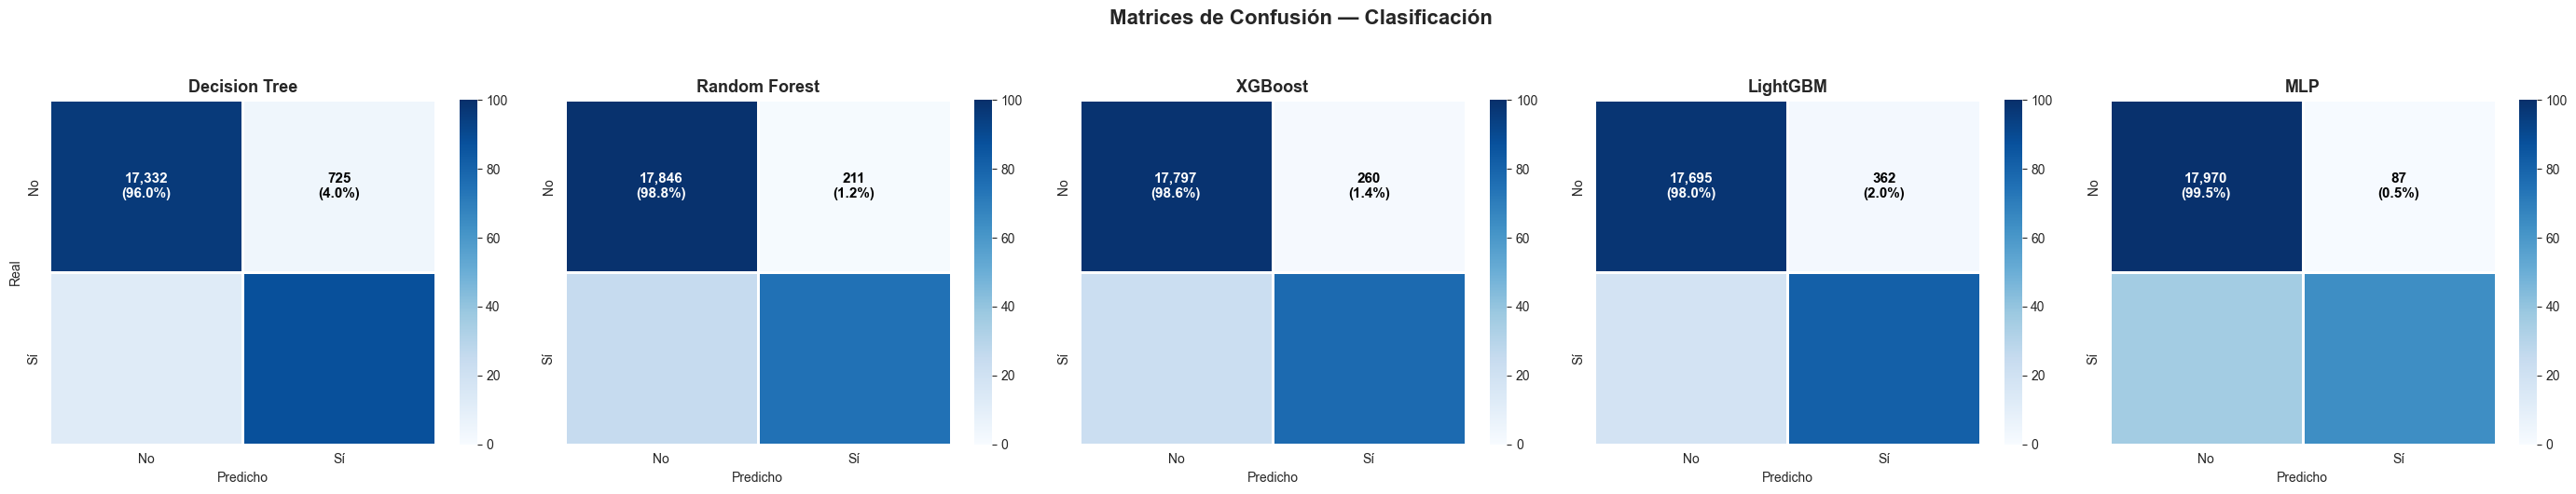

In [12]:
fig, axes = plt.subplots(1, 5, figsize=(28, 5))

for idx, (nombre, modelo) in enumerate(modelos_clasif.items()):
    y_pred = modelo.predict(X_test_c)
    cm = confusion_matrix(y_test_c, y_pred)
    cm_pct = cm.astype('float') / cm.sum(axis=1, keepdims=True) * 100
    
    labels = np.array([
        [f'{cm[i,j]:,}\n({cm_pct[i,j]:.1f}%)' for j in range(2)]
        for i in range(2)
    ])
    
    sns.heatmap(cm_pct, annot=labels, fmt='', cmap='Blues', ax=axes[idx],
                xticklabels=['No', 'Sí'], yticklabels=['No', 'Sí'],
                vmin=0, vmax=100,
                annot_kws={'fontsize': 11, 'fontweight': 'bold'},
                linewidths=2, linecolor='white')
    
    # Forzar color de texto según el fondo
    for text_obj in axes[idx].texts:
        # Obtener posición del texto para saber en qué celda está
        x, y = text_obj.get_position()
        valor = cm_pct[int(y), int(x)]
        text_obj.set_color('white' if valor > 50 else 'black')
    
    axes[idx].set_title(nombre, fontsize=13, fontweight='bold')
    axes[idx].set_xlabel('Predicho')
    if idx == 0:
        axes[idx].set_ylabel('Real')

plt.suptitle('Matrices de Confusión — Clasificación', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig('./datasets/prepared/fig_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.2 Comparativa de modelos de clasificación

COMPARATIVA DE MODELOS — CLASIFICACIÓN


,F1-score,Precision,Recall,ROC-AUC,Tiempo (s)
MLP,0.7111,0.7995,0.6402,0.9726,67.0887
Random Forest,0.7006,0.6580,0.7491,0.9717,7.8690
XGBoost,0.6874,0.6176,0.7749,0.9770,1.9303
LightGBM,0.6558,0.5492,0.8137,0.9652,2.4105
Decision Tree,0.5462,0.3963,0.8782,0.9263,1.0534


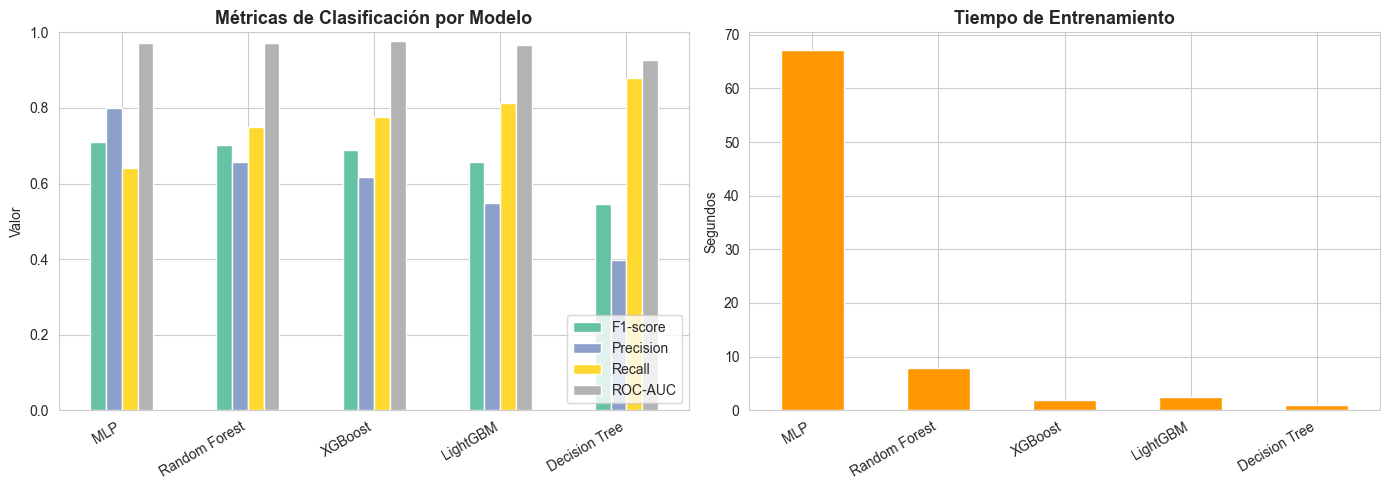


🏆 Mejor modelo (F1-score): MLP (0.7111)


In [11]:
# ============================================================================
# TABLA COMPARATIVA
# ============================================================================

df_resultados_c = pd.DataFrame(resultados_clasif).T
df_resultados_c = df_resultados_c.sort_values('F1-score', ascending=False)

print('COMPARATIVA DE MODELOS — CLASIFICACIÓN')
print('='*70)
display(df_resultados_c.round(4))

# Gráfico comparativo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

metricas_plot = ['F1-score', 'Precision', 'Recall', 'ROC-AUC']
df_resultados_c[metricas_plot].plot(kind='bar', ax=axes[0], colormap='Set2')
axes[0].set_title('Métricas de Clasificación por Modelo', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Valor')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, ha='right')
axes[0].legend(loc='lower right')
axes[0].set_ylim(0, 1)

df_resultados_c['Tiempo (s)'].plot(kind='bar', ax=axes[1], color='#FF9800')
axes[1].set_title('Tiempo de Entrenamiento', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Segundos')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.savefig('./datasets/prepared/fig_comparativa_clasificacion.png', dpi=150, bbox_inches='tight')
plt.show()

mejor = df_resultados_c.index[0]
print(f'\n🏆 Mejor modelo (F1-score): {mejor} ({df_resultados_c.loc[mejor, "F1-score"]:.4f})')

### 4.3 Importancia de features (clasificación)

¿Qué variables son más importantes para predecir paradas?
Analizamos los modelos basados en árboles (que ofrecen `feature_importances_`).

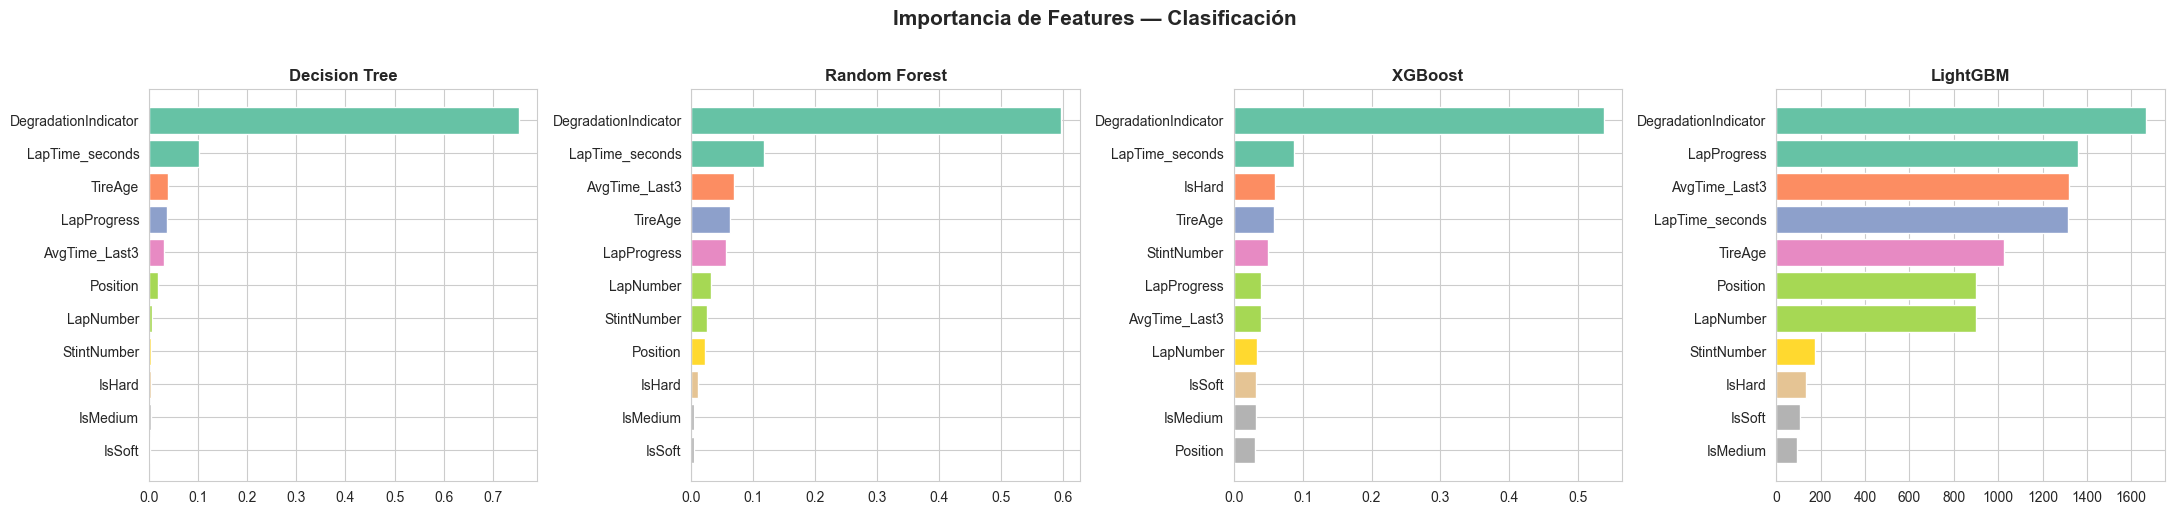

In [13]:
# ============================================================================
# FEATURE IMPORTANCE
# ============================================================================

modelos_con_importancia = ['Decision Tree', 'Random Forest', 'XGBoost', 'LightGBM']

fig, axes = plt.subplots(1, 4, figsize=(22, 5))

for idx, nombre in enumerate(modelos_con_importancia):
    modelo = modelos_clasif[nombre]
    importancias = modelo.feature_importances_
    indices = np.argsort(importancias)[::-1]
    
    axes[idx].barh(
        [features_clasif[i] for i in indices],
        importancias[indices],
        color=plt.cm.Set2(np.linspace(0, 1, len(features_clasif)))
    )
    axes[idx].set_title(nombre, fontsize=12, fontweight='bold')
    axes[idx].invert_yaxis()

plt.suptitle('Importancia de Features — Clasificación', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('./datasets/prepared/fig_feature_importance_clasif.png', dpi=150, bbox_inches='tight')
plt.show()

---
# PARTE B: REGRESIÓN (¿Cuántas vueltas hasta la próxima parada?)
---

## 5. Entrenamiento de modelos de regresión

**Target:** `LapsUntilNextStop` = vueltas restantes hasta la próxima parada en boxes.

**Métricas:**
- **RMSE** (Root Mean Squared Error): penaliza errores grandes
- **MAE** (Mean Absolute Error): error promedio en vueltas
- **R²** (Coeficiente de determinación): varianza explicada

In [14]:
# ============================================================================
# DEFINIR MODELOS DE REGRESIÓN
# ============================================================================

modelos_regres = {
    'Decision Tree': DecisionTreeRegressor(
        max_depth=10,
        random_state=RANDOM_STATE
    ),
    'Random Forest': RandomForestRegressor(
        n_estimators=200,
        max_depth=15,
        n_jobs=-1,
        random_state=RANDOM_STATE
    ),
    'XGBoost': XGBRegressor(
        n_estimators=300,
        max_depth=8,
        learning_rate=0.1,
        random_state=RANDOM_STATE
    ),
    'LightGBM': LGBMRegressor(
        n_estimators=300,
        max_depth=8,
        learning_rate=0.1,
        verbose=-1,
        random_state=RANDOM_STATE
    ),
    'MLP': MLPRegressor(
        hidden_layer_sizes=(128, 64, 32),
        activation='relu',
        solver='adam',
        max_iter=300,
        early_stopping=True,
        validation_fraction=0.1,
        random_state=RANDOM_STATE
    ),
}

print(f'Modelos definidos: {list(modelos_regres.keys())}')

Modelos definidos: ['Decision Tree', 'Random Forest', 'XGBoost', 'LightGBM', 'MLP']


In [15]:
# ============================================================================
# ENTRENAR Y EVALUAR CADA MODELO
# ============================================================================

resultados_regres = {}

for nombre, modelo in modelos_regres.items():
    print(f'\n{"="*60}')
    print(f'Entrenando: {nombre}')
    print(f'{"="*60}')
    
    inicio = time.time()
    
    # MLP necesita datos normalizados, el resto no
    if nombre == 'MLP':
        modelo.fit(X_train_r_norm, y_train_r)
        y_pred = modelo.predict(X_test_r_norm)
    else:
        modelo.fit(X_train_r, y_train_r)
        y_pred = modelo.predict(X_test_r)
    
    duracion = time.time() - inicio
    
    # Calcular métricas
    rmse = np.sqrt(mean_squared_error(y_test_r, y_pred))
    mae = mean_absolute_error(y_test_r, y_pred)
    r2 = r2_score(y_test_r, y_pred)
    
    resultados_regres[nombre] = {
        'RMSE': rmse,
        'MAE': mae,
        'R²': r2,
        'Tiempo (s)': duracion
    }
    
    print(f'  RMSE: {rmse:.2f} vueltas')
    print(f'  MAE:  {mae:.2f} vueltas')
    print(f'  R²:   {r2:.4f}')
    print(f'  Tiempo: {duracion:.1f}s')

print('\n✅ Todos los modelos de regresión entrenados')


Entrenando: Decision Tree
  RMSE: 8.79 vueltas
  MAE:  6.41 vueltas
  R²:   0.2773
  Tiempo: 0.4s

Entrenando: Random Forest
  RMSE: 8.39 vueltas
  MAE:  6.15 vueltas
  R²:   0.3424
  Tiempo: 20.4s

Entrenando: XGBoost
  RMSE: 8.54 vueltas
  MAE:  6.26 vueltas
  R²:   0.3178
  Tiempo: 1.8s

Entrenando: LightGBM
  RMSE: 8.44 vueltas
  MAE:  6.22 vueltas
  R²:   0.3345
  Tiempo: 0.9s

Entrenando: MLP
  RMSE: 8.66 vueltas
  MAE:  6.32 vueltas
  R²:   0.2992
  Tiempo: 45.6s

✅ Todos los modelos de regresión entrenados


### 5.1 Comparativa de modelos de regresión

COMPARATIVA DE MODELOS — REGRESIÓN


,RMSE,MAE,R²,Tiempo (s)
Random Forest,8.3869,6.1498,0.3424,20.4453
LightGBM,8.4372,6.2162,0.3345,0.9287
XGBoost,8.5419,6.2627,0.3178,1.7773
MLP,8.6580,6.3212,0.2992,45.5534
Decision Tree,8.7920,6.4140,0.2773,0.4308


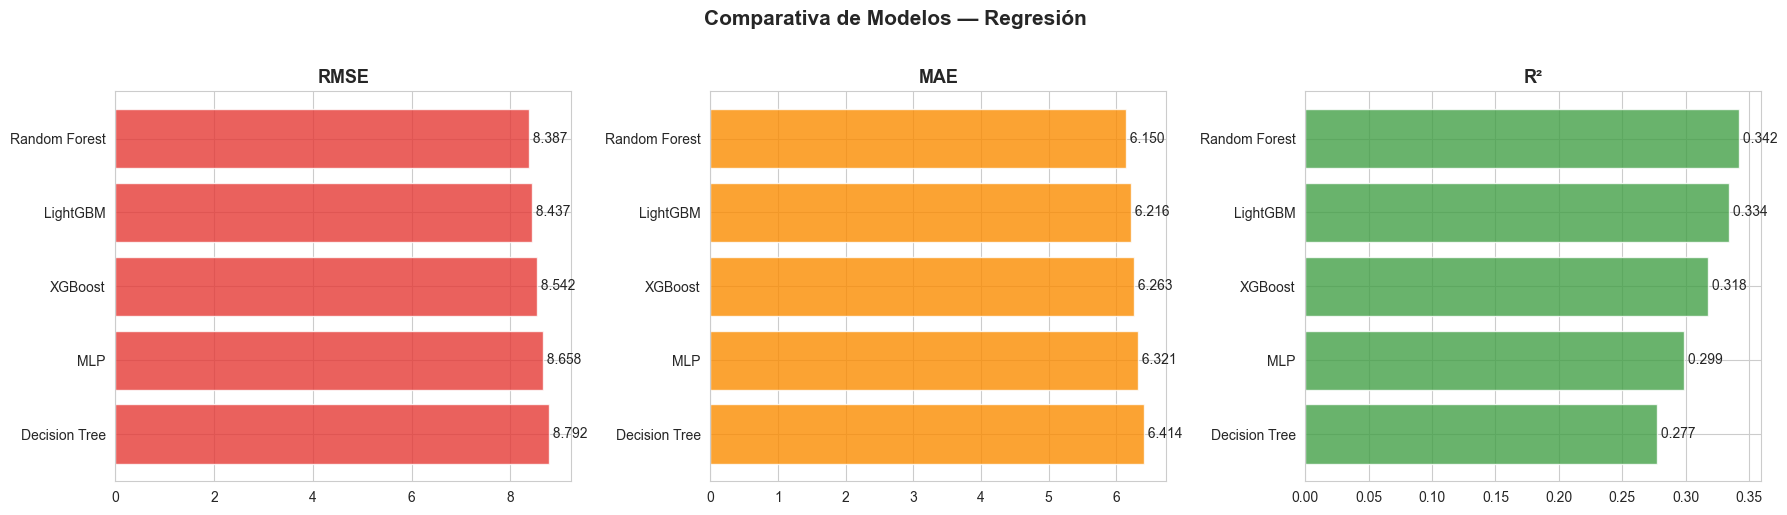


🏆 Mejor modelo (RMSE): Random Forest (8.39 vueltas)


In [16]:
# ============================================================================
# TABLA COMPARATIVA
# ============================================================================

df_resultados_r = pd.DataFrame(resultados_regres).T
df_resultados_r = df_resultados_r.sort_values('RMSE', ascending=True)

print('COMPARATIVA DE MODELOS — REGRESIÓN')
print('='*70)
display(df_resultados_r.round(4))

# Gráfico comparativo
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (metrica, color, ascend) in enumerate([
    ('RMSE', '#E53935', True),
    ('MAE', '#FB8C00', True),
    ('R²', '#43A047', False)
]):
    datos = df_resultados_r.sort_values(metrica, ascending=ascend)
    axes[idx].barh(datos.index, datos[metrica], color=color, alpha=0.8)
    axes[idx].set_title(metrica, fontsize=13, fontweight='bold')
    axes[idx].invert_yaxis()
    for i, v in enumerate(datos[metrica]):
        axes[idx].text(v, i, f' {v:.3f}', va='center', fontsize=10)

plt.suptitle('Comparativa de Modelos — Regresión', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('./datasets/prepared/fig_comparativa_regresion.png', dpi=150, bbox_inches='tight')
plt.show()

mejor_r = df_resultados_r.index[0]
print(f'\n🏆 Mejor modelo (RMSE): {mejor_r} ({df_resultados_r.loc[mejor_r, "RMSE"]:.2f} vueltas)')

### 5.2 Predicho vs. Real (regresión)

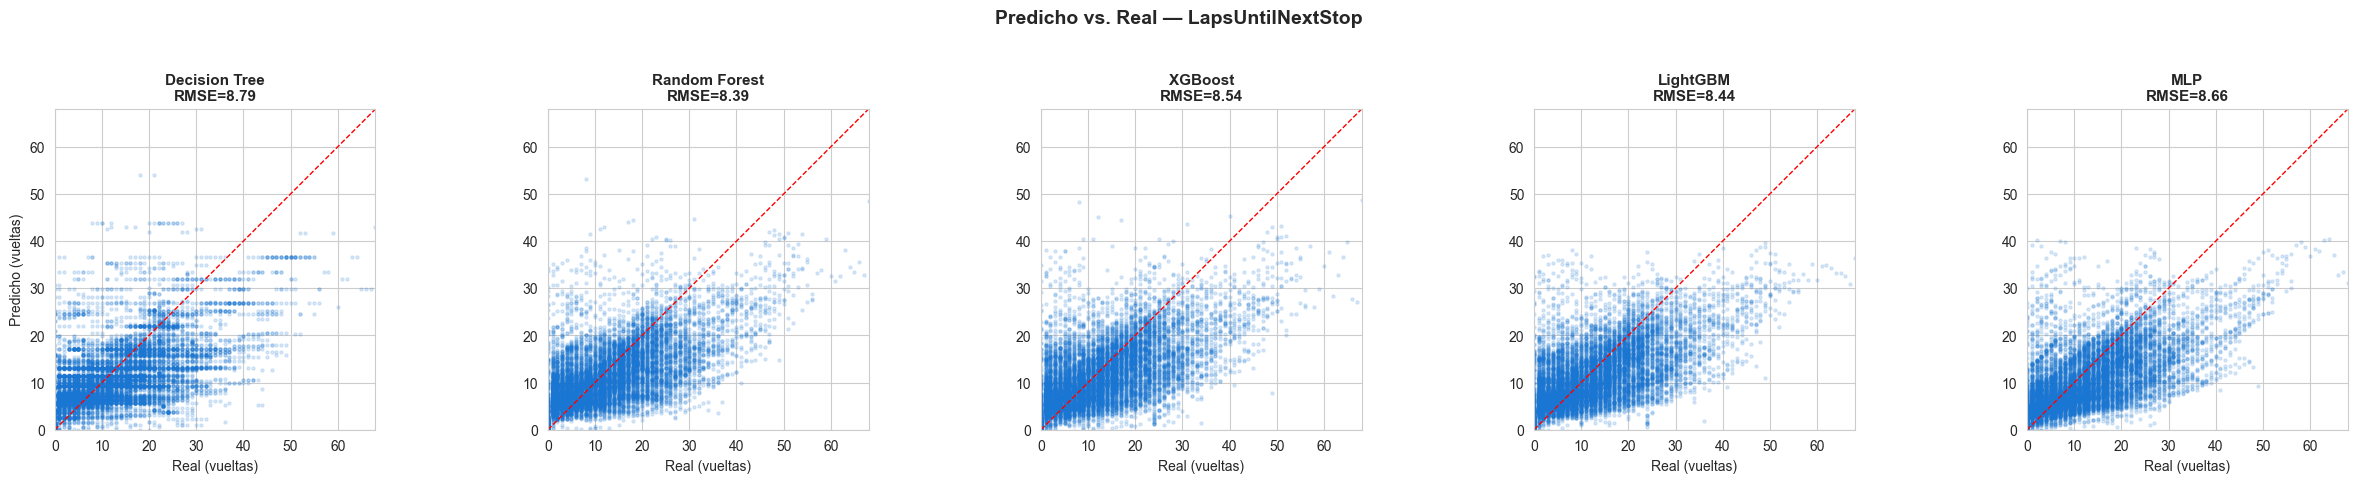

In [17]:
# ============================================================================
# SCATTER: PREDICHO vs REAL
# ============================================================================

fig, axes = plt.subplots(1, 5, figsize=(25, 4.5))

for idx, (nombre, modelo) in enumerate(modelos_regres.items()):
    if nombre == 'MLP':
        y_pred = modelo.predict(X_test_r_norm)
    else:
        y_pred = modelo.predict(X_test_r)
    
    axes[idx].scatter(y_test_r, y_pred, alpha=0.15, s=5, color='#1976D2')
    
    # Línea de predicción perfecta
    lim_max = max(y_test_r.max(), y_pred.max())
    axes[idx].plot([0, lim_max], [0, lim_max], 'r--', linewidth=1, label='Perfecto')
    
    rmse = np.sqrt(mean_squared_error(y_test_r, y_pred))
    axes[idx].set_title(f'{nombre}\nRMSE={rmse:.2f}', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel('Real (vueltas)')
    if idx == 0:
        axes[idx].set_ylabel('Predicho (vueltas)')
    axes[idx].set_aspect('equal')
    axes[idx].set_xlim(0, lim_max)
    axes[idx].set_ylim(0, lim_max)

plt.suptitle('Predicho vs. Real — LapsUntilNextStop', fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig('./datasets/prepared/fig_pred_vs_real.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.3 Importancia de features (regresión)

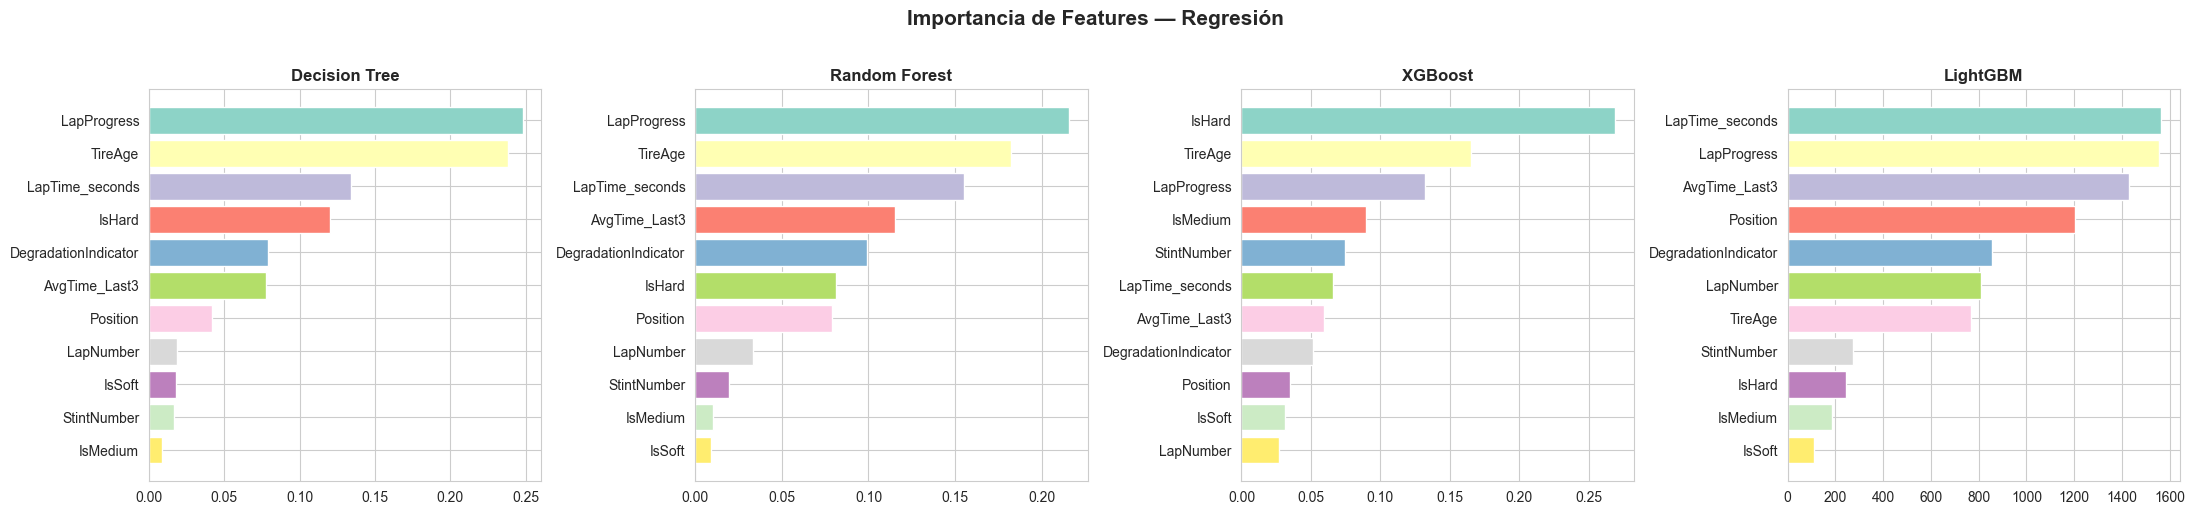

In [18]:
# ============================================================================
# FEATURE IMPORTANCE — REGRESIÓN
# ============================================================================

modelos_con_importancia_r = ['Decision Tree', 'Random Forest', 'XGBoost', 'LightGBM']

fig, axes = plt.subplots(1, 4, figsize=(22, 5))

for idx, nombre in enumerate(modelos_con_importancia_r):
    modelo = modelos_regres[nombre]
    importancias = modelo.feature_importances_
    indices = np.argsort(importancias)[::-1]
    
    axes[idx].barh(
        [features_regres[i] for i in indices],
        importancias[indices],
        color=plt.cm.Set3(np.linspace(0, 1, len(features_regres)))
    )
    axes[idx].set_title(nombre, fontsize=12, fontweight='bold')
    axes[idx].invert_yaxis()

plt.suptitle('Importancia de Features — Regresión', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('./datasets/prepared/fig_feature_importance_regres.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Resumen global y conclusiones

In [19]:
# ============================================================================
# RESUMEN FINAL
# ============================================================================

print('='*70)
print('RESUMEN GLOBAL — COMPARATIVA DE MODELOS')
print('='*70)

print(f'\n📊 CLASIFICACIÓN (¿Parada sí/no?)')
print(f'   Métrica principal: F1-score')
print(f'   Train: {len(X_train_c):,} muestras | Test: {len(X_test_c):,} muestras')
print(f'   Desbalance: {y_train_c.mean():.2%} positivos')
print()
for nombre, res in sorted(resultados_clasif.items(), key=lambda x: x[1]['F1-score'], reverse=True):
    print(f'   {nombre:20s}  F1={res["F1-score"]:.4f}  P={res["Precision"]:.4f}  R={res["Recall"]:.4f}  AUC={res["ROC-AUC"]:.4f}')

print(f'\n📈 REGRESIÓN (Vueltas hasta próxima parada)')
print(f'   Métrica principal: RMSE (en vueltas)')
print(f'   Train: {len(X_train_r):,} muestras | Test: {len(X_test_r):,} muestras')
print(f'   Target: {TARGET_REG}')
print()
for nombre, res in sorted(resultados_regres.items(), key=lambda x: x[1]['RMSE']):
    print(f'   {nombre:20s}  RMSE={res["RMSE"]:.2f}  MAE={res["MAE"]:.2f}  R²={res["R²"]:.4f}')

print(f'\n🏆 MEJORES MODELOS')
mejor_c = max(resultados_clasif, key=lambda x: resultados_clasif[x]['F1-score'])
mejor_r = min(resultados_regres, key=lambda x: resultados_regres[x]['RMSE'])
print(f'   Clasificación: {mejor_c} (F1={resultados_clasif[mejor_c]["F1-score"]:.4f})')
print(f'   Regresión:     {mejor_r} (RMSE={resultados_regres[mejor_r]["RMSE"]:.2f} vueltas)')

print(f'\n✅ Notebook 3 completado')
print(f'\n📁 Figuras guardadas en ./datasets/prepared/')

RESUMEN GLOBAL — COMPARATIVA DE MODELOS

📊 CLASIFICACIÓN (¿Parada sí/no?)
   Métrica principal: F1-score
   Train: 74,392 muestras | Test: 18,599 muestras
   Desbalance: 3.24% positivos

   MLP                   F1=0.7111  P=0.7995  R=0.6402  AUC=0.9726
   Random Forest         F1=0.7006  P=0.6580  R=0.7491  AUC=0.9717
   XGBoost               F1=0.6874  P=0.6176  R=0.7749  AUC=0.9770
   LightGBM              F1=0.6558  P=0.5492  R=0.8137  AUC=0.9652
   Decision Tree         F1=0.5462  P=0.3963  R=0.8782  AUC=0.9263

📈 REGRESIÓN (Vueltas hasta próxima parada)
   Métrica principal: RMSE (en vueltas)
   Train: 42,691 muestras | Test: 10,673 muestras
   Target: LapsUntilNextStop

   Random Forest         RMSE=8.39  MAE=6.15  R²=0.3424
   LightGBM              RMSE=8.44  MAE=6.22  R²=0.3345
   XGBoost               RMSE=8.54  MAE=6.26  R²=0.3178
   MLP                   RMSE=8.66  MAE=6.32  R²=0.2992
   Decision Tree         RMSE=8.79  MAE=6.41  R²=0.2773

🏆 MEJORES MODELOS
   Clasificació

## 7. Exportar resultados

In [20]:
# ============================================================================
# GUARDAR TABLAS DE RESULTADOS
# ============================================================================

df_resultados_c.round(4).to_csv('./datasets/prepared/resultados_clasificacion.csv')
df_resultados_r.round(4).to_csv('./datasets/prepared/resultados_regresion.csv')

print('Archivos generados:')
print('  ✓ resultados_clasificacion.csv')
print('  ✓ resultados_regresion.csv')
print('  ✓ fig_confusion_matrices.png')
print('  ✓ fig_comparativa_clasificacion.png')
print('  ✓ fig_comparativa_regresion.png')
print('  ✓ fig_pred_vs_real.png')
print('  ✓ fig_feature_importance_clasif.png')
print('  ✓ fig_feature_importance_regres.png')

print(f'\n🎯 PRÓXIMOS PASOS:')
print(f'   1. Optimizar hiperparámetros del mejor modelo (GridSearch/Optuna)')
print(f'   2. Validación cruzada temporal (TimeSeriesSplit)')
print(f'   3. Análisis SHAP para interpretabilidad')
print(f'   4. Escribir Capítulos 4-7 del TFM con estos resultados')

Archivos generados:
  ✓ resultados_clasificacion.csv
  ✓ resultados_regresion.csv
  ✓ fig_confusion_matrices.png
  ✓ fig_comparativa_clasificacion.png
  ✓ fig_comparativa_regresion.png
  ✓ fig_pred_vs_real.png
  ✓ fig_feature_importance_clasif.png
  ✓ fig_feature_importance_regres.png

🎯 PRÓXIMOS PASOS:
   1. Optimizar hiperparámetros del mejor modelo (GridSearch/Optuna)
   2. Validación cruzada temporal (TimeSeriesSplit)
   3. Análisis SHAP para interpretabilidad
   4. Escribir Capítulos 4-7 del TFM con estos resultados


---

### Notas para el TFM

**Capítulo 4 (Desarrollo):** Describir cada modelo, sus hiperparámetros y la estrategia de manejo de desbalance.

**Capítulo 5 (Resultados):** Incluir las tablas comparativas y figuras generadas en este notebook.

**Capítulo 6 (Discusión):** Analizar por qué ciertos modelos funcionan mejor, qué features son más importantes,
y comparar con los resultados de Sasikumar et al. (2025), García Tejada (2023) y Todd et al. (2025).

**Capítulo 7 (Conclusiones):** Responder a los objetivos OE1-OE5 del TFM con los resultados obtenidos.

---

**Fin del Notebook 3.** Continuar con optimización de hiperparámetros si el director lo requiere.